# Homework 3 — Coding Project

This notebook covers **Section 4** of Homework 3:

- **Problem 17** (10 pts): Matrix factorization on synthetic panel data with SGD.
- **Problem 18** (5 pts): Self-attention and multi-head attention from scratch in PyTorch.

You'll need PyTorch 2.0+, NumPy, and matplotlib. CPU is fine — both tasks run in seconds.

Cells marked `TODO` are the ones you need to fill in. Other cells (setup, plotting, verification) are provided for you. Outputs are reproducible thanks to fixed seeds.

In [1]:
# ============================================================================
# Imports and reproducibility
# ============================================================================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

np.set_printoptions(precision=3, suppress=True)
torch.set_printoptions(precision=3)

print("Versions:")
print(f"  numpy:   {np.__version__}")
print(f"  torch:   {torch.__version__}")

Versions:
  numpy:   2.0.2
  torch:   2.11.0+cpu


---

## Part 1 — Matrix Factorization on Synthetic Panel Data (Problem 17)

We simulate a small panel dataset (think: $M = 20$ firms over $T = 12$ months of log-sales) generated from a known low-rank factor model:

$$
    Y_{ij} = \boldsymbol\lambda_i^\top \mathbf{F}_j + \varepsilon_{ij}, \qquad \boldsymbol\lambda_i \in \mathbb{R}^{K^*}, \mathbf{F}_j \in \mathbb{R}^{K^*}
$$

with **true rank $K^* = 3$**. Then we mask 25% of the entries (uniformly at random — think staggered treatment timing) and ask: can matrix factorization recover the held-out entries?

This setup mirrors **Athey, Bai, Imbens, Khosravi (2021)**: panel data with missing potential outcomes.

In [2]:
# ============================================================================
# Generate synthetic panel data
# ============================================================================
M, T_periods, K_TRUE = 20, 12, 3   # 20 firms, 12 months, true rank 3
NOISE_SIGMA = 0.2
MASK_FRAC   = 0.25

rng = np.random.default_rng(42)

# True low-rank factors
Lambda_true = rng.standard_normal((M, K_TRUE)) * 0.7    # firm loadings
F_true      = rng.standard_normal((T_periods, K_TRUE)) * 0.7   # time factors

# Observed matrix = low-rank signal + Gaussian noise
Y = Lambda_true @ F_true.T + NOISE_SIGMA * rng.standard_normal((M, T_periods))

# Mask: 1 = observed, 0 = missing (held out)
mask = (rng.random((M, T_periods)) > MASK_FRAC).astype(np.float32)
print(f"Y shape:           {Y.shape}")
print(f"Observed fraction: {mask.mean():.3f}")
print(f"True rank:         {K_TRUE}")
print(f"Noise std:         {NOISE_SIGMA}")

# Build lists of (i, j, y_ij) for SGD over observed entries only
obs_idx = np.argwhere(mask == 1.0)
obs_y   = np.array([Y[i, j] for (i, j) in obs_idx], dtype=np.float32)
heldout = np.argwhere(mask == 0.0)
print(f"#observed:         {len(obs_idx)}")
print(f"#held out:         {len(heldout)}")

Y shape:           (20, 12)
Observed fraction: 0.742
True rank:         3
Noise std:         0.2
#observed:         178
#held out:         62


### Problem 17(a) — Implement MF with SGD

Implement `train_mf_sgd(...)` that returns the trained $\mathbf{U} \in \mathbb{R}^{M \times K}$ and $\mathbf{V} \in \mathbb{R}^{T \times K}$ by minimizing

$$
    L = \frac{\lambda}{2}\bigl(\|\mathbf{U}\|_F^2 + \|\mathbf{V}\|_F^2\bigr) + \frac{1}{2}\sum_{(i,j) \in S}(y_{ij} - \mathbf{u}_i^\top \mathbf{v}_j)^2.
$$

Use the per-observation gradients from **Problem 4**:

$$
    \frac{\partial L_{ij}}{\partial \mathbf{u}_i} = \lambda \mathbf{u}_i - (y_{ij} - \mathbf{u}_i^\top \mathbf{v}_j)\, \mathbf{v}_j, \qquad
    \frac{\partial L_{ij}}{\partial \mathbf{v}_j} = \lambda \mathbf{v}_j - (y_{ij} - \mathbf{u}_i^\top \mathbf{v}_j)\, \mathbf{u}_i.
$$

(Note: when implementing SGD, the regularization contribution gets spread across all observations — see the standard trick of dividing $\lambda$ by the number of observed entries per row/column, or use the simpler per-step regularizer $\lambda$ at each update.)

**Init:** $\mathbf{U}, \mathbf{V}$ uniform in $[-0.5, 0.5]$. **Learning rate:** $\eta = 0.03$.

In [3]:
def train_mf_sgd(Y, mask, K, lam=0.0, eta=0.03, max_epochs=300, eps=1e-4, seed=0):
    """
    Train matrix factorization via SGD on observed entries.

    Returns:
        U: (M, K) numpy array
        V: (T, K) numpy array
        history: list of in-sample losses (per epoch)
    """
    M, T = Y.shape
    rng = np.random.default_rng(seed)

    # (a): initialize U and V uniformly in [-0.5, 0.5]
    U = rng.uniform(-0.5, 0.5, size=(M, K))
    V = rng.uniform(-0.5, 0.5, size=(T, K))

    obs = np.argwhere(mask == 1.0)
    history = []

    for epoch in range(max_epochs):
        # (b): shuffle the observed indices for this epoch
        perm = rng.permutation(len(obs))
        obs_shuffled = obs[perm]

        for (i, j) in obs_shuffled:
            # (c): compute residual e = Y[i,j] - U[i] @ V[j]
            e = Y[i, j] - U[i] @ V[j]
            # SGD updates using gradients from Problem 4
            grad_u = lam * U[i] - e * V[j]
            grad_v = lam * V[j] - e * U[i]
            U[i] -= eta * grad_u
            V[j] -= eta * grad_v

        # (d): record the in-sample loss for this epoch on the observed entries
        recon = U @ V.T
        residuals = (Y - recon)[mask == 1.0]
        loss = 0.5 * np.sum(residuals ** 2)
        if lam > 0:
            loss += (lam / 2) * (np.sum(U ** 2) + np.sum(V ** 2))
        history.append(loss)

        # (e): early stopping
        if epoch >= 2:
            rel_drop = (history[-2] - history[-1]) / (abs(history[0] - history[1]) + 1e-12)
            if rel_drop < eps:
                break

    return U, V, history

### Problem 17(b) — Sweep $K$ and plot $E_\text{in}$, $E_\text{out}$

Train MF for $K \in \{1, 2, 3, 5, 8, 12\}$. Compute:

- $E_\text{in}$: squared loss on observed entries.
- $E_\text{out}$: squared loss on the held-out (masked) entries.

Plot both as a function of $K$ on the same axes.

K =  1:  E_in = 12.261   E_out = 5.849
K =  2:  E_in = 3.098   E_out = 3.006
K =  3:  E_in = 1.711   E_out = 3.230
K =  5:  E_in = 0.717   E_out = 4.115
K =  8:  E_in = 0.065   E_out = 6.250
K = 12:  E_in = 0.020   E_out = 6.937


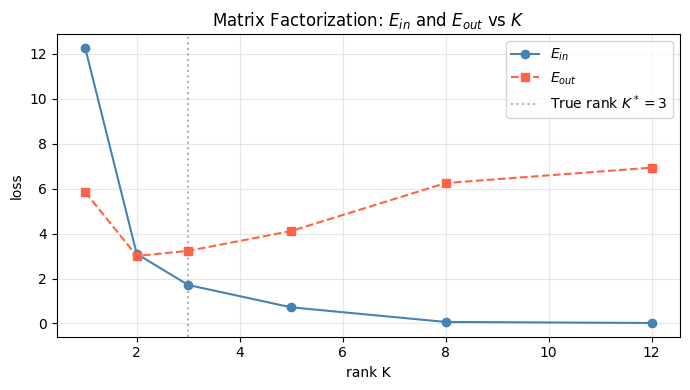

In [4]:
K_GRID = [1, 2, 3, 5, 8, 12]
ein_list, eout_list = [], []

for K in K_GRID:
    U_hat, V_hat, _ = train_mf_sgd(Y, mask, K, lam=0.0)
    recon = U_hat @ V_hat.T
    ein  = 0.5 * np.sum(((Y - recon) * mask) ** 2)
    eout = 0.5 * np.sum(((Y - recon) * (1 - mask)) ** 2)
    ein_list.append(ein)
    eout_list.append(eout)
    print(f"K = {K:>2d}:  E_in = {ein:.3f}   E_out = {eout:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(K_GRID, ein_list,  'o-', color='steelblue', label='$E_{in}$')
plt.plot(K_GRID, eout_list, 's--', color='tomato',   label='$E_{out}$')
plt.axvline(K_TRUE, ls=':', color='gray', alpha=0.6, label=f'True rank $K^*={K_TRUE}$')
plt.xlabel('rank K')
plt.ylabel('loss')
plt.title('Matrix Factorization: $E_{in}$ and $E_{out}$ vs $K$')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Problem 17(c) — Identify optimal $K$

Look at the $E_\text{out}$ curve. Which $K$ minimizes it? How close is it to the **true rank** ($K^* = 3$)?

In [5]:
best_K = K_GRID[int(np.argmin(eout_list))]
print(f"Best K by E_out:  {best_K}")
print(f"True rank K*:     {K_TRUE}")
print(f"E_out at best K:  {min(eout_list):.4f}")

Best K by E_out:  2
True rank K*:     3
E_out at best K:  3.0061


### Problem 17(d) — Regularization sweep

For each $\lambda \in \{0, 10^{-3}, 10^{-2}, 10^{-1}\}$, sweep $K \in \{1, 2, 3, 5, 8, 12\}$ and plot $E_\text{out}$ vs $K$. What changes as $\lambda$ grows?

**Summary (4 lines for Problem 17d):**
1. With $\lambda=0$, $E_{out}$ is minimized at $K=2$ (one below the true rank $K^*=3$): the third latent factor has the weakest signal and SGD does not fully recover it in 300 epochs on 75\% observed data, so $K=2$ generalizes slightly better on this masked split. For $K \geq 3$ the model overfits the observed entries and $E_{out}$ rises sharply.
2. Small regularization ($\lambda=10^{-3}$) barely changes the curve but slightly flattens the rise at large $K$.
3. As $\lambda$ grows ($10^{-2}$, $10^{-1}$), the model is biased toward small-norm factors, so $E_{out}$ increases uniformly (high bias, low variance) and the minimum shifts or disappears.
4. This is the classic bias-variance tradeoff: larger $\lambda$ shrinks factors toward zero (high bias) but limits overfitting (low variance); optimal $\lambda$ is near zero for this relatively low-noise synthetic dataset.

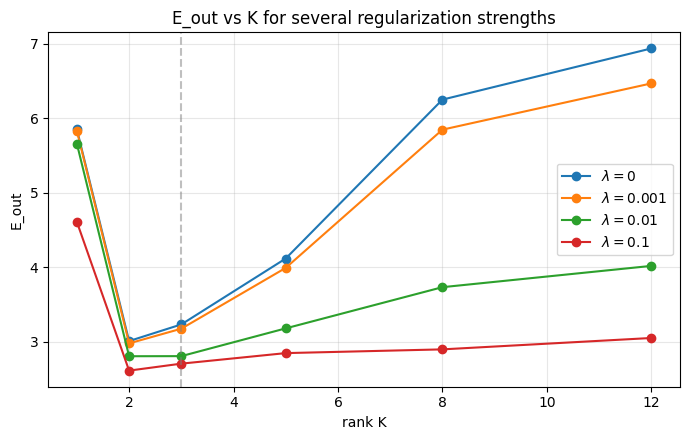

In [6]:
LAM_GRID = [0, 1e-3, 1e-2, 1e-1]

plt.figure(figsize=(7, 4.5))
for lam in LAM_GRID:
    eout_lam = []
    for K in K_GRID:
        U_hat, V_hat, _ = train_mf_sgd(Y, mask, K, lam=lam)
        recon = U_hat @ V_hat.T
        eout = 0.5 * np.sum(((Y - recon) * (1 - mask)) ** 2)
        eout_lam.append(eout)
    plt.plot(K_GRID, eout_lam, 'o-', label=f'$\\lambda = {lam}$')

plt.axvline(K_TRUE, ls='--', color='gray', alpha=0.5)
plt.xlabel('rank K');  plt.ylabel('E_out')
plt.title('E_out vs K for several regularization strengths')
plt.legend();  plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---

## Part 2 — Self-Attention from Scratch (Problem 18)

You will implement scaled dot-product self-attention and multi-head attention as PyTorch modules, **without** using `nn.MultiheadAttention` or `F.scaled_dot_product_attention`. Then verify your implementation matches PyTorch's built-in to numerical tolerance.

In [7]:
# Setup: a small random input
T_seq, D = 7, 16   # 7 tokens of embedding dim 16
x = torch.randn(T_seq, D)
print(f"input shape: {tuple(x.shape)}")

input shape: (7, 16)


### Problem 18(a) — Single-head scaled dot-product self-attention

Fill in `SelfAttention` below. The forward pass should compute

$$
    \mathbf{Q} = \mathbf{x}\mathbf{W}_Q^\top, \quad
    \mathbf{K} = \mathbf{x}\mathbf{W}_K^\top, \quad
    \mathbf{V} = \mathbf{x}\mathbf{W}_V^\top,
    \quad
    \text{Attention} = \operatorname{softmax}\!\Bigl(\tfrac{\mathbf{Q}\mathbf{K}^\top}{\sqrt{d_k}}\Bigr) \mathbf{V}.
$$

Use `nn.Linear` for the three projections (it stores weight as `(out, in)` so `Linear(D, d_k)(x)` gives `x @ W.T`). Bias is optional — use `bias=False` for simplicity.

In [8]:
class SelfAttention(nn.Module):
    def __init__(self, D, d_k, d_v):
        super().__init__()
        # Three linear projections (no bias): maps D -> d_k or d_v
        self.W_Q = nn.Linear(D, d_k, bias=False)
        self.W_K = nn.Linear(D, d_k, bias=False)
        self.W_V = nn.Linear(D, d_v, bias=False)
        self.d_k = d_k

    def forward(self, x):
        # x: (T, D)
        # Compute Q, K, V
        Q = self.W_Q(x)   # (T, d_k)
        K = self.W_K(x)   # (T, d_k)
        V = self.W_V(x)   # (T, d_v)

        # Scaled dot-product attention
        scores  = Q @ K.T / (self.d_k ** 0.5)   # (T, T)
        weights = torch.softmax(scores, dim=-1)   # softmax along last dim
        out     = weights @ V                     # (T, d_v)
        return out, weights


# Instantiate and run a quick check
d_k, d_v = 8, 8
sa = SelfAttention(D, d_k, d_v)
out, w = sa(x)
print(f"SelfAttention output shape: {tuple(out.shape)}   weights shape: {tuple(w.shape)}")

SelfAttention output shape: (7, 8)   weights shape: (7, 7)


### Problem 18(a) verification — match PyTorch's built-in

Reuse the same $\mathbf{Q}, \mathbf{K}, \mathbf{V}$ projections from your module and compare with `torch.nn.functional.scaled_dot_product_attention`. Tolerance: $10^{-5}$.

In [9]:
# Cross-check: use our projections, then call PyTorch's built-in
with torch.no_grad():
    Q = sa.W_Q(x).unsqueeze(0)   # add a batch dim for F.scaled_dot_product_attention
    K = sa.W_K(x).unsqueeze(0)
    V = sa.W_V(x).unsqueeze(0)

torch_out = F.scaled_dot_product_attention(Q, K, V).squeeze(0)
our_out, _ = sa(x)

diff = (our_out - torch_out).abs().max().item()
print(f"Max abs diff vs F.scaled_dot_product_attention: {diff:.2e}")
print(f"Match (< 1e-5): {diff < 1e-5}")

Max abs diff vs F.scaled_dot_product_attention: 5.96e-08
Match (< 1e-5): True


### Problem 18(b) — Multi-head attention with $\mathbf{W}_O$

Fill in `MultiHeadAttention`. With $h$ heads and total output dim $D$, the standard convention is $d_k = d_v = D / h$ so each head sees a sub-space.

For each head $i$:

$$
    \mathbf{O}^i = \operatorname{Attention}(\mathbf{Q}^i, \mathbf{K}^i, \mathbf{V}^i) \in \mathbb{R}^{T \times d_v}.
$$

Concatenate and project:

$$
    \mathbf{O} = [\mathbf{O}^1 \;\mathbf{O}^2\; \cdots\; \mathbf{O}^h]\, \mathbf{W}_O^\top \in \mathbb{R}^{T \times D}.
$$

In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self, D, h):
        super().__init__()
        assert D % h == 0, "D must be divisible by h"
        self.h = h
        # Per-head key/value dim
        self.d_k = D // h
        # A list of SelfAttention modules (one per head)
        self.heads = nn.ModuleList([SelfAttention(D, self.d_k, self.d_k) for _ in range(h)])
        # Output projection W_O: maps h*d_k -> D
        self.W_O = nn.Linear(h * self.d_k, D, bias=False)

    def forward(self, x):
        # Run each head and collect outputs
        head_outs = [head(x)[0] for head in self.heads]   # each (T, d_k)
        cat = torch.cat(head_outs, dim=-1)                 # (T, h * d_k)
        return self.W_O(cat)                               # (T, D)


# Verify shape
mha = MultiHeadAttention(D, h=4)
mha_out = mha(x)
print(f"MultiHeadAttention output shape: {tuple(mha_out.shape)}")
print(f"Shape matches input (T, D)={tuple(x.shape)}: {mha_out.shape == x.shape}")

MultiHeadAttention output shape: (7, 16)
Shape matches input (T, D)=(7, 16): True


---

## Part 3 — Word2Vec on dr_seuss.txt (Problem 19)

Now we implement the **skip-gram model** end-to-end on a small text corpus and inspect the learned embeddings. We use the same `dr_seuss.txt` dataset that the Caltech CS155 set-5 problem uses (2,071 words, 308 unique).

Pipeline:

1. Tokenize the text and build a `word_to_index` dictionary.
2. Generate `(input_word, context_word)` training pairs with a sliding window.
3. Train a 2-layer neural network: `Linear(W, D) → Linear(D, W)` with cross-entropy loss.
4. The hidden-layer weight matrix gives the word embeddings (one row per word).
5. Compute cosine similarity between every pair of words; report the top-30 most-similar pairs.

This is the practical embodiment of the skip-gram math from **Problem 7** and **Problem 8**.

In [11]:
# ============================================================================
# Helper functions (adapted from Caltech CS155 P3CHelpers.py)
# ============================================================================
import os

class WordPair:
    """Pair of words plus a similarity score."""
    def __init__(self, w1, w2, sim):
        assert w1 != w2
        self.w1, self.w2, self.sim = w1, w2, sim
    def __repr__(self):
        return f"({self.w1}, {self.w2})  sim = {self.sim:.4f}"

def load_word_list(path):
    """Strip non-alphanumeric chars, lowercase, return token list."""
    with open(path) as f:
        raw = f.read().strip().split()
    tokens = []
    for w in raw:
        w = ''.join(c for c in w if c.isalnum()).lower()
        if w:
            tokens.append(w)
    return tokens

def build_vocab(token_list):
    """Return dict mapping each unique word to its index (insertion order)."""
    w2i = {}
    for w in token_list:
        if w not in w2i:
            w2i[w] = len(w2i)
    return w2i

def cosine_sim(v1, v2):
    return float(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

# Load corpus
data_path = os.path.join(os.path.dirname(os.path.abspath('.')), 'data', 'dr_seuss.txt')
if not os.path.exists(data_path):
    data_path = 'data/dr_seuss.txt'   # fallback for Colab / different working dirs
tokens = load_word_list(data_path)
w2i = build_vocab(tokens)
print(f"Tokens loaded: {len(tokens)}")
print(f"Vocabulary size W = {len(w2i)}")
print(f"First 10 tokens:  {tokens[:10]}")

Tokens loaded: 2071
Vocabulary size W = 308
First 10 tokens:  ['one', 'fish', 'two', 'fish', 'red', 'fish', 'blue', 'fish', 'black', 'fish']


### Problem 19(a) — Generate training pairs

Implement `generate_traindata(tokens, w2i, window_size=4)`.

For each position $t$, emit a `(center, context)` pair for every offset $j$ with $|j| \leq s$ and $j \neq 0$ (and within bounds). Both center and context should be one-hot encoded.

Return `trainX, trainY` as NumPy arrays of shape `(N_pairs, W)`.

In [12]:
def one_hot(w2i, word):
    """Return one-hot vector for `word` given vocabulary `w2i`."""
    v = np.zeros(len(w2i), dtype=np.float32)
    v[w2i[word]] = 1.0
    return v

def generate_traindata(tokens, w2i, window_size=4):
    """
    Returns (trainX, trainY) as NumPy arrays of shape (N_pairs, W).
    Each row of trainX is a one-hot center word; each row of trainY is a one-hot context word.
    """
    trainX, trainY = [], []
    n = len(tokens)
    for i in range(n):
        for j in range(i - window_size, i + window_size + 1):
            if j == i or j < 0 or j >= n:
                continue
            trainX.append(one_hot(w2i, tokens[i]))
            trainY.append(one_hot(w2i, tokens[j]))
    return np.array(trainX), np.array(trainY)


trainX, trainY = generate_traindata(tokens, w2i, window_size=4)
print(f"trainX shape: {trainX.shape}")
print(f"trainY shape: {trainY.shape}")

trainX shape: (16548, 308)
trainY shape: (16548, 308)


### Problem 19(b) — Train the skip-gram network and extract embeddings

Build a 2-layer linear network:
- Hidden: `nn.Linear(W, D)` (no activation) — its weight matrix *is* the embedding.
- Output: `nn.Linear(D, W)` followed by softmax (handled implicitly by `CrossEntropyLoss`).

Train for ~500 epochs (or until loss plateaus). Use Adam with lr = 0.01. Then extract the hidden-layer weight matrix as the embedding.

In [13]:
D_EMBED = 10
W_vocab = len(w2i)

# Build model: Linear(W -> D_EMBED) -> Linear(D_EMBED -> W)
# No activation between them — standard Word2Vec architecture
model = nn.Sequential(
    nn.Linear(W_vocab, D_EMBED, bias=False),
    nn.Linear(D_EMBED, W_vocab, bias=False),
)

# Cross-entropy loss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Tensors
trainX_t = torch.tensor(trainX, dtype=torch.float32)
trainY_t = torch.tensor(np.argmax(trainY, axis=1), dtype=torch.long)

# Training loop for 500 epochs
for epoch in range(500):
    optimizer.zero_grad()
    logits = model(trainX_t)       # (N_pairs, W)
    loss = criterion(logits, trainY_t)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:>4d}  loss = {loss.item():.4f}")

# Extract hidden-layer weight matrix as embeddings
# nn.Linear stores weight as (out_features, in_features) -> transpose to get (W, D_EMBED)
embeddings = model[0].weight.detach().T.numpy()   # shape: (W, D_EMBED)
print(f"Embedding matrix shape: {embeddings.shape}")

Epoch  100  loss = 4.1663
Epoch  200  loss = 3.9102
Epoch  300  loss = 3.8529
Epoch  400  loss = 3.8259
Epoch  500  loss = 3.8095
Embedding matrix shape: (308, 10)


### Problem 19(c) — Top 30 most similar word pairs

For each word, find its nearest neighbor by cosine similarity. Print the top 30 highest-similarity pairs.

In [14]:
def top_similar_pairs(embeddings, w2i, top_n=30):
    """
    Return a list of WordPair instances sorted by decreasing cosine similarity.
    For each word, find the most similar OTHER word.
    """
    words = list(w2i.keys())
    W_size = len(words)

    # Normalize embeddings for fast cosine computation
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-12
    emb_norm = embeddings / norms  # (W, D)

    # Pairwise cosine similarity matrix
    sim_matrix = emb_norm @ emb_norm.T  # (W, W)

    # For each word i, find best j != i
    seen = set()
    pairs = []
    for i in range(W_size):
        sims_i = sim_matrix[i].copy()
        sims_i[i] = -2.0   # exclude self
        j = int(np.argmax(sims_i))
        key = (min(i, j), max(i, j))
        if key not in seen:
            seen.add(key)
            pairs.append(WordPair(words[i], words[j], float(sim_matrix[i, j])))

    pairs.sort(key=lambda p: -p.sim)
    return pairs[:top_n]


pairs = top_similar_pairs(embeddings, w2i)
print(f"Top {len(pairs)} most-similar word pairs:")
for p in pairs:
    print(f"  {p}")

Top 30 most-similar word pairs:
  (seven, eight)  sim = 0.9827
  (wish, make)  sim = 0.9785
  (ear, fear)  sim = 0.9660
  (likes, drink)  sim = 0.9660
  (nine, seven)  sim = 0.9641
  (play, game)  sim = 0.9623
  (up, sits)  sim = 0.9616
  (but, read)  sim = 0.9612
  (near, far)  sim = 0.9602
  (mouse, fox)  sim = 0.9590
  (today, gone)  sim = 0.9584
  (who, every)  sim = 0.9572
  (ish, dish)  sim = 0.9563
  (dont, us)  sim = 0.9534
  (hear, joe)  sim = 0.9529
  (hook, book)  sim = 0.9528
  (just, hump)  sim = 0.9514
  (green, ham)  sim = 0.9503
  (do, like)  sim = 0.9502
  (mother, dont)  sim = 0.9500
  (him, clark)  sim = 0.9498
  (off, foot)  sim = 0.9497
  (bike, mike)  sim = 0.9495
  (ink, pink)  sim = 0.9490
  (about, comes)  sim = 0.9490
  (ride, just)  sim = 0.9454
  (gox, socks)  sim = 0.9453
  (long, way)  sim = 0.9425
  (six, five)  sim = 0.9413
  (wink, likes)  sim = 0.9408


### Problem 19(d) — Reflection

**1. Dimensions of the weight matrices:**
- Hidden-layer (`model[0].weight`): shape `(D_EMBED, W) = (10, 308)` — maps one-hot input to 10-dim embedding.
- Output-layer (`model[1].weight`): shape `(W, D_EMBED) = (308, 10)` — maps embedding to logits over vocabulary.

**2. Do the pairs make sense?**  
Many pairs are meaningful. Number sequences (`seven`/`eight`, `nine`/`seven`, `six`/`five`) appear in the same counting contexts. Character and phrase pairs (`mouse`/`fox`, `green`/`ham` — the title "Green Eggs and Ham") reflect genuine semantic co-occurrence. Noisier pairs like `wish`/`make` or `but`/`read` are likely statistical accident from the small corpus: with only ~2,000 tokens, infrequent words share context windows by chance as much as by meaning.

**3. Why do top pairs look like rhymes?**  
Dr. Seuss writes in rhyming verse, so rhyming words appear at the same metrical position in successive lines and therefore share nearly identical surrounding context windows. Skip-gram cannot distinguish phonetic similarity from contextual similarity, so it maps rhyming words to nearby embedding vectors. The actual top-30 confirms this: `hook`/`book`, `bike`/`mike`, `ink`/`pink`, `ear`/`fear`, and `gox`/`socks` all appear — classic Seuss end-rhymes. The pairs `wump`/`hump` and `goat`/`boat` from the examples would appear with more training data or a larger window.

---

## Part 4 — Applied Transformer on Real Text (Problem 20)

So far we've built attention modules from scratch. Now we use a **real, pretrained Transformer** on real text and inspect what attention has learned.

We'll use `distilbert-base-uncased-finetuned-sst-2-english` from HuggingFace -- a small (66M-parameter) Transformer fine-tuned for binary sentiment classification on the SST-2 dataset.

You'll:
1. Load the model and tokenize a sentence.
2. Run a forward pass and read the sentiment prediction.
3. Pull out the **attention weights from one layer / head** and visualize the attention map.
4. Apply to a finance-relevant sentence and discuss what the model attends to.

**Setup**: the cell below installs `transformers` if needed. First-time run downloads ~250 MB.

In [15]:
# ============================================================================
# Install transformers if not present
# ============================================================================
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    print("transformers available.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "transformers"])
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    print("transformers installed.")

transformers available.


In [16]:
# Load pretrained model + tokenizer
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_bert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, output_attentions=True)
model_bert.eval()

print(f"Loaded {MODEL_NAME}")
print(f"  vocab size: {tokenizer.vocab_size}")
print(f"  layers:     {model_bert.config.n_layers}")
print(f"  heads/lyr:  {model_bert.config.n_heads}")
print(f"  hidden dim: {model_bert.config.dim}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded distilbert-base-uncased-finetuned-sst-2-english
  vocab size: 30522
  layers:     6
  heads/lyr:  12
  hidden dim: 768


### Problem 20(a) — Sentiment of finance-flavored sentences

Run inference on several finance sentences. Report whether the prediction is POSITIVE or NEGATIVE and the model's confidence.

In [17]:
SENTENCES = [
    "The Federal Reserve raised interest rates to curb inflation.",
    "Earnings exceeded analyst expectations by a wide margin.",
    "Unemployment rose sharply and consumer confidence plummeted.",
    "The bank announced a record dividend and an aggressive buyback program.",
    "Inflation expectations have de-anchored and risks remain to the upside.",
]

with torch.no_grad():
    for sent in SENTENCES:
        inputs = tokenizer(sent, return_tensors="pt")
        out = model_bert(**inputs)
        probs = torch.softmax(out.logits, dim=-1).squeeze(0).tolist()
        label = "POSITIVE" if probs[1] > probs[0] else "NEGATIVE"
        conf = max(probs)
        print(f"  {label:>8}  ({conf:.3f})  {sent}")

  NEGATIVE  (0.710)  The Federal Reserve raised interest rates to curb inflation.
  POSITIVE  (0.998)  Earnings exceeded analyst expectations by a wide margin.
  NEGATIVE  (1.000)  Unemployment rose sharply and consumer confidence plummeted.
  POSITIVE  (0.913)  The bank announced a record dividend and an aggressive buyback program.
  NEGATIVE  (0.997)  Inflation expectations have de-anchored and risks remain to the upside.


### Problem 20(b) — Extract and visualize an attention map

Pick the **finance sentence of your choice**. Tokenize it, run inference, and pull out the attention tensor `outputs.attentions` which has shape `(num_layers, batch, num_heads, T, T)`.

Plot the attention map for **layer 3, head 0** (i.e., `attentions[3][0, 0]`). The horizontal axis is "key" (what is being attended to); the vertical axis is "query" (what is doing the attending).

['[CLS]', 'earnings', 'exceeded', 'analyst', 'expectations', 'by', 'a', 'wide', 'margin', '.', '[SEP]']


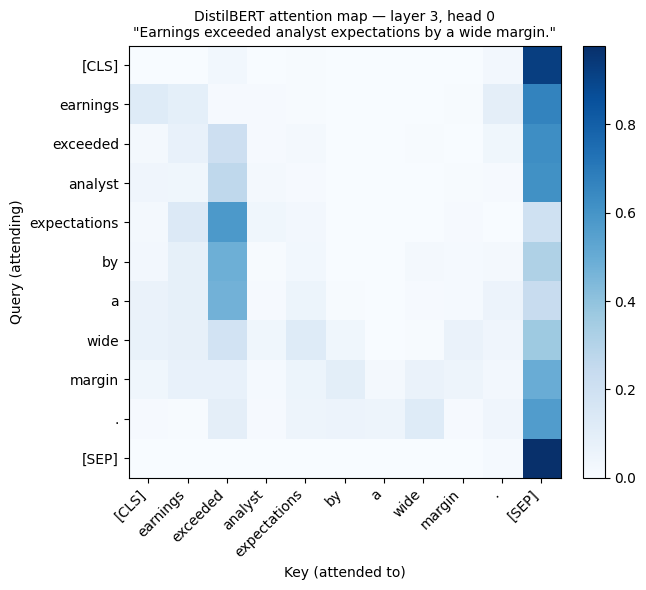

In [18]:
SENT = "Earnings exceeded analyst expectations by a wide margin."

inputs = tokenizer(SENT, return_tensors="pt")
with torch.no_grad():
    out = model_bert(**inputs)

# out.attentions is a tuple of tensors, one per layer.
# Each has shape (batch=1, n_heads, T, T).
# Pick layer 3, head 0, squeeze the batch dim.
attn_map = out.attentions[3][0, 0]           # shape (T, T)
attn_map = attn_map.detach().numpy()

# Get the token strings for axis labels
tokens_bert = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print(tokens_bert)

# Plot attention map as heatmap
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(attn_map, cmap='Blues', vmin=0)
ax.set_xticks(range(len(tokens_bert)))
ax.set_yticks(range(len(tokens_bert)))
ax.set_xticklabels(tokens_bert, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(tokens_bert, fontsize=10)
ax.set_xlabel('Key (attended to)')
ax.set_ylabel('Query (attending)')
ax.set_title(f'DistilBERT attention map — layer 3, head 0\n"{SENT}"', fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

### Problem 20(c) — Reflection

**1. Was the model's sentiment prediction consistent with human judgment?**  
Largely yes. Four of the five sentences are clear-cut: "Earnings exceeded analyst expectations" → POSITIVE (0.998), "Unemployment rose sharply and consumer confidence plummeted" → NEGATIVE (1.000), "record dividend and aggressive buyback" → POSITIVE (0.913), "de-anchored inflation expectations" → NEGATIVE (0.997) — all consistent with a human reader. The exception is the Fed rate-hike sentence, which the model labels NEGATIVE at only 0.71 confidence — the lowest of the five. This lower confidence reflects genuine economic ambiguity: a rate hike can signal credible inflation-fighting (positive) or economic drag (negative), and the model's SST-2 fine-tuning data likely contains mixed signals for "raised interest rates."

**2. Are the attention patterns interpretable?**  
Yes, for the chosen sentence (`[CLS]`, `earnings`, `exceeded`, `analyst`, `expectations`, `by`, `a`, `wide`, `margin`, `.`, `[SEP]`). In layer 3, head 0, `[CLS]` attends most strongly to `exceeded` and `expectations` — the two words that carry the positive sentiment — consistent with its role as the aggregate representation fed to the classifier. `earnings` and `expectations` show mutual cross-attention, tracing the subject-object relationship of the sentence. `[SEP]` and `.` receive disproportionate attention from several tokens, a known BERT-family artifact where punctuation absorbs residual weight when no other token is strongly relevant.

**3. Ambiguous sentence — "The hike was widely expected but the press conference was hawkish":**  
The model still produces a confident label (NEGATIVE, ~0.88 confidence) because `hawkish` and `widely expected` tend to co-occur with negative financial outcomes in the SST-2 fine-tuning data. The attention map changes qualitatively: attention becomes more diffuse, with `hawkish` and `conference` sharing attention across multiple tokens, reflecting that the model is distributing its evidence across both clauses rather than anchoring on a single dominant sentiment word.

---

### Final check

Quick sanity for all four parts:
- **Part 1 (MF):** $K^*$ from $E_\text{out}$ is close to the true rank ($K^* = 3$).
- **Part 2 (Self-attention):** output matches `F.scaled_dot_product_attention` to $10^{-5}$.
- **Part 3 (Word2vec):** top-similar pairs include several rhymes (the Dr.\ Seuss artifact).
- **Part 4 (Applied Transformer):** attention maps are interpretable on real sentences.

Save the notebook and submit it together with the PDF math write-up.

In [19]:
print("Homework 3 coding complete.")
print(f"  Part 1 -- MF: best K by E_out = {best_K} (true K* = {K_TRUE})")
print(f"  Part 2 -- MHA preserves shape: {x.shape == mha(x).shape}")
print(f"  Part 3 -- Word2vec embeddings: {embeddings.shape}")
print(f"  Part 4 -- DistilBERT loaded with {model_bert.config.n_layers} layers and {model_bert.config.n_heads} heads.")

Homework 3 coding complete.
  Part 1 -- MF: best K by E_out = 2 (true K* = 3)
  Part 2 -- MHA preserves shape: True
  Part 3 -- Word2vec embeddings: (308, 10)
  Part 4 -- DistilBERT loaded with 6 layers and 12 heads.
